# **Trabajo Práctico N°2: Clasificación de Intenciones**
### **Ciencia de Datos 2026 - UTN Santa Fe**

**Objetivo:** Desarrollar un modelo capaz de clasificar intenciones a partir de consultas en inglés utilizando el dataset `intent.csv` (77 categorías).

---

## **1. Importación de Librerías y Configuración**
En esta celda importamos todas las dependencias necesarias para las distintas etapas del proyecto: manipulación de datos, graficación, procesamiento del lenguaje natural (NLP), aprendizaje automático tradicional, balanceo de clases y aprendizaje profundo (PyTorch).

In [22]:
# --- Ciencia de Datos & Gráficos ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Procesamiento de Lenguaje Natural (NLP) & Text Vectorization ---
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import spacy
import gensim
from gensim.models import Word2Vec
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# --- Machine Learning Tradicional & Evaluación ---
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# --- Balanceo de Clases ---
from imblearn.over_sampling import SMOTE

# --- Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- Configuraciones de estilo para gráficos ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# --- Descarga de recursos necesarios para NLTK ---
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("¡Librerías importadas y configuradas con éxito!")
print(f"PyTorch versión: {torch.__version__}")

¡Librerías importadas y configuradas con éxito!
PyTorch versión: 2.12.0+cpu


In [23]:
# Carga del dataset
df = pd.read_csv("./Documentos/intent.csv")

In [24]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones del dataset: 13083 filas x 2 columnas


In [25]:
print(f"\nPrimeras filas:")
df.head()


Primeras filas:


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [26]:
# Información general: tipos de datos y memoria
print("=== Información del DataFrame ===")
df.info()
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())
print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")

=== Información del DataFrame ===
<class 'pandas.DataFrame'>
RangeIndex: 13083 entries, 0 to 13082
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      13083 non-null  str  
 1   category  13083 non-null  str  
dtypes: str(2)
memory usage: 204.6 KB

=== Valores nulos por columna ===
text        0
category    0
dtype: int64

=== Filas duplicadas: 0 ===


In [27]:
# --- Conteo y porcentaje por clase ---
class_counts = df["category"].value_counts()
class_pcts   = df["category"].value_counts(normalize=True).mul(100).round(2)

class_summary = pd.DataFrame({
    "Cantidad": class_counts,
    "Porcentaje (%)": class_pcts
})

print(f"Número de categorías únicas: {df['category'].nunique()}")
print(f"\nMínimo de muestras por clase : {class_counts.min()} — Clase: '{class_counts.idxmin()}'")
print(f"Máximo de muestras por clase : {class_counts.max()} — Clase: '{class_counts.idxmax()}'")
print(f"Promedio de muestras por clase: {class_counts.mean():.1f}")
print()


Número de categorías únicas: 77

Mínimo de muestras por clase : 75 — Clase: 'contactless_not_working'
Máximo de muestras por clase : 227 — Clase: 'card_payment_fee_charged'
Promedio de muestras por clase: 169.9



In [28]:
class_summary

,Cantidad,Porcentaje (%)
category,,
card_payment_fee_charged,227,1.74
direct_debit_payment_not_recognised,222,1.70
balance_not_updated_after_cheque_or_cash_deposit,221,1.69
wrong_amount_of_cash_received,220,1.68
cash_withdrawal_charge,217,1.66
...,...,...
lost_or_stolen_card,122,0.93
card_swallowed,101,0.77
card_acceptance,99,0.76


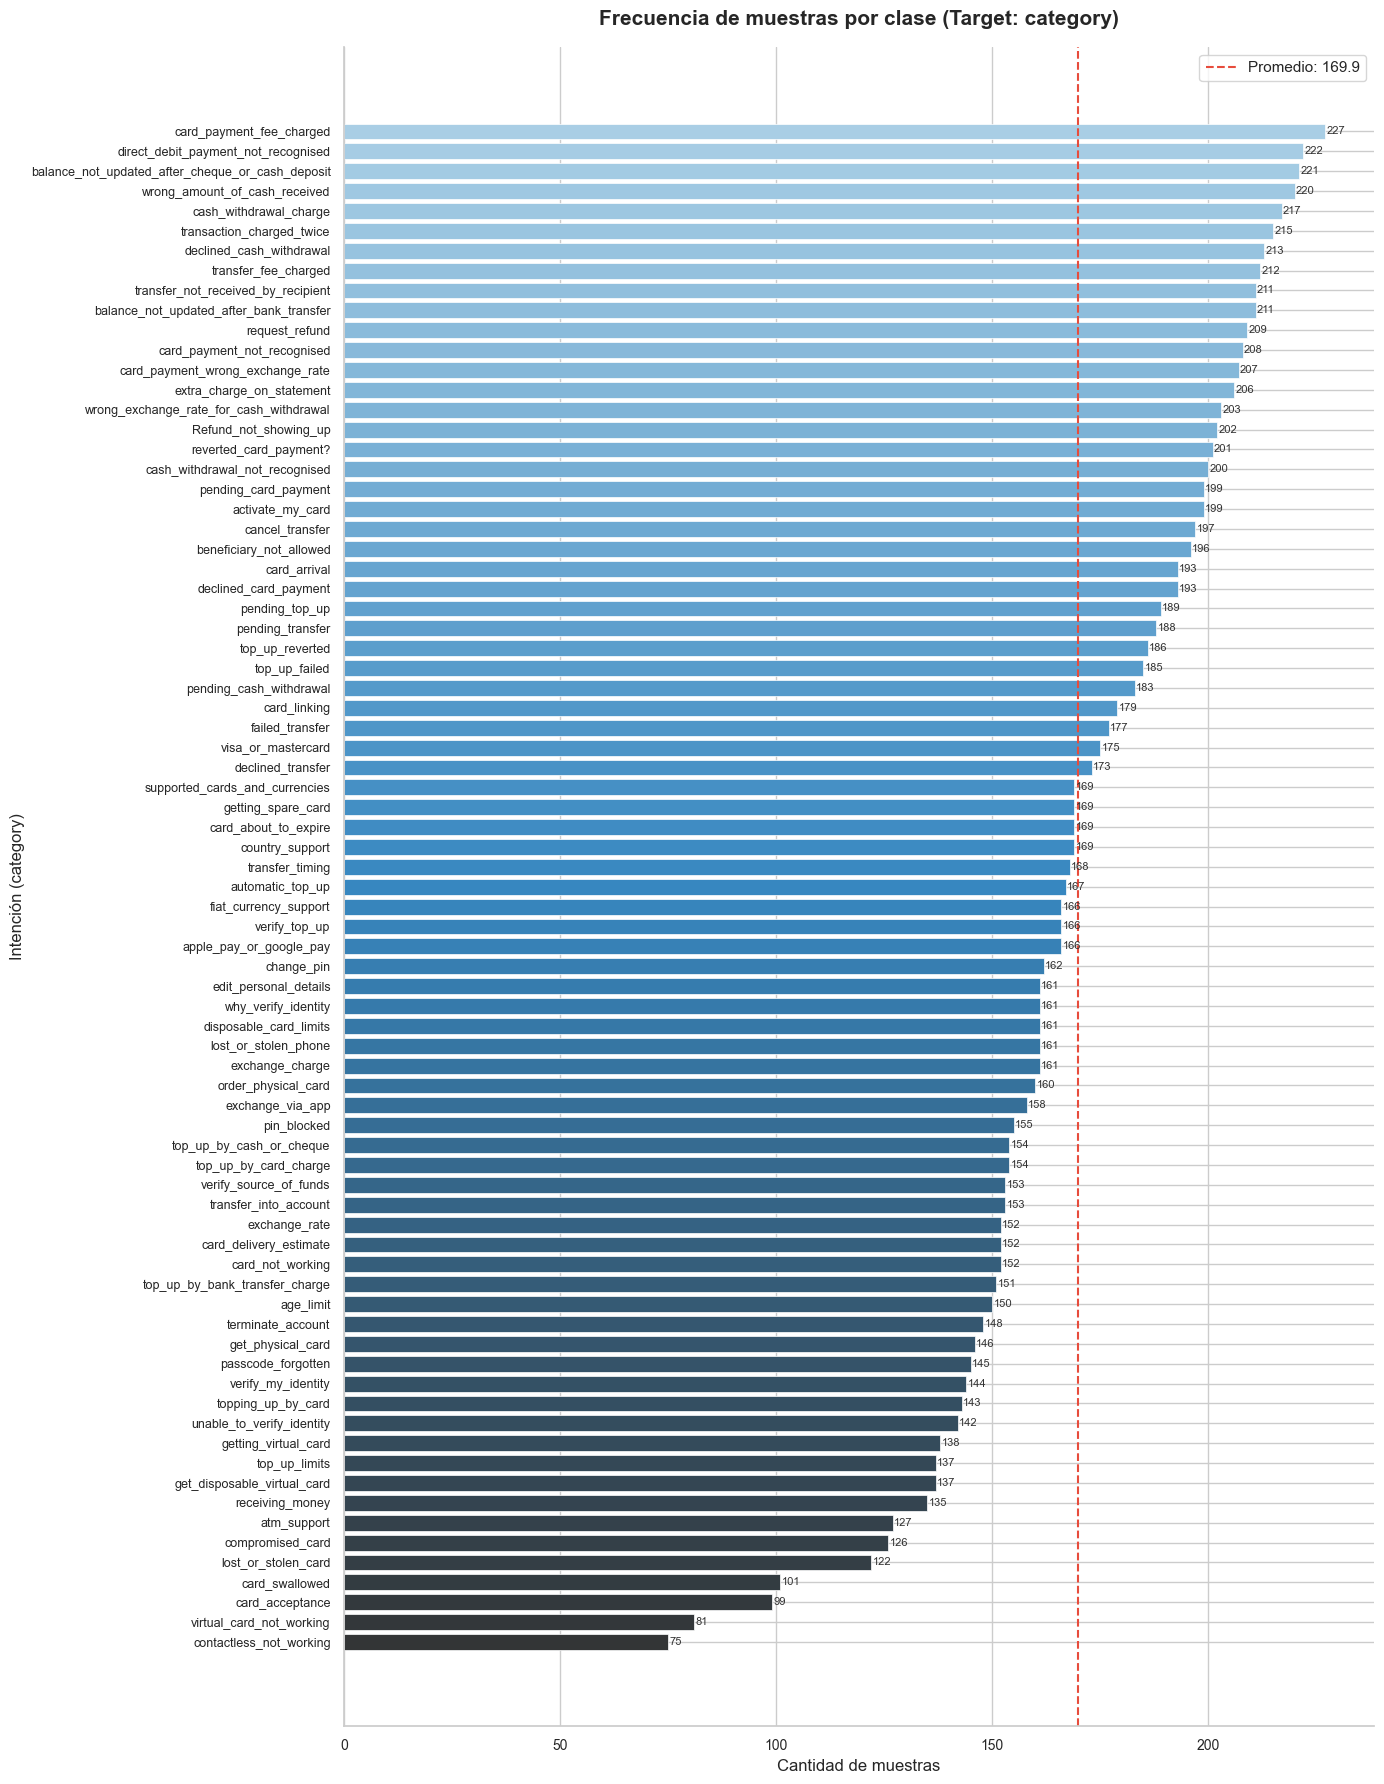

In [29]:
# --- Histograma de frecuencia por clase (ordenado de mayor a menor) ---
fig, ax = plt.subplots(figsize=(14, 18))

# Paleta de colores degradada por frecuencia
palette = sns.color_palette("Blues_d", n_colors=len(class_counts))

bars = ax.barh(
    class_counts.index,
    class_counts.values,
    color=palette,
    edgecolor="white",
    linewidth=0.5
)

# Línea del promedio
avg = class_counts.mean()
ax.axvline(avg, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Promedio: {avg:.1f}")

# Etiquetas de cantidad al final de cada barra
for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center", ha="left",
        fontsize=8, color="#333333"
    )

ax.set_title("Frecuencia de muestras por clase (Target: category)", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Cantidad de muestras", fontsize=12)
ax.set_ylabel("Intención (category)", fontsize=12)
ax.invert_yaxis()   # la clase más frecuente arriba
ax.legend(fontsize=11)
ax.tick_params(axis="y", labelsize=9)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()


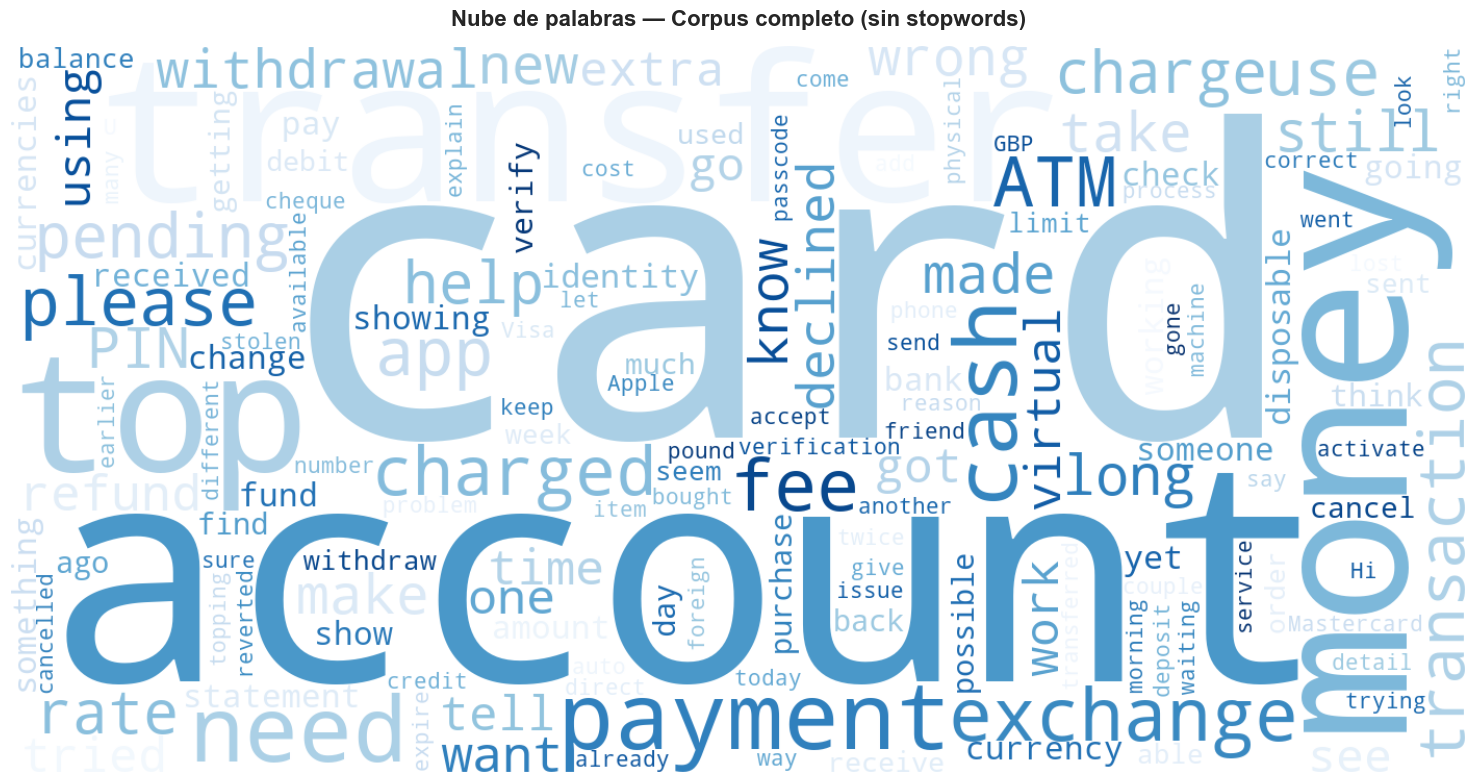

In [30]:
# Todo el texto del corpus unido en un solo string
corpus_text = " ".join(df["text"].astype(str).tolist())

# Stopwords combinadas: las de wordcloud + las de nltk en inglés
stop_words = set(STOPWORDS)
stop_words.update(stopwords.words("english"))

wc_global = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    stopwords=stop_words,
    colormap="Blues",
    max_words=150,
    collocations=False,   # evita repetir bigramas
    contour_color="steelblue",
    contour_width=1
).generate(corpus_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc_global, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Corpus completo (sin stopwords)", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


In [31]:
# Crear columnas de longitud sobre el texto crudo
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df["text"].astype(str).apply(len)

print("=== Estadísticas de longitud ===")
print(df[["word_count", "char_count"]].describe().round(2))


=== Estadísticas de longitud ===
       word_count  char_count
count    13083.00    13083.00
mean        11.71       58.24
std          7.64       39.56
min          2.00       13.00
25%          7.00       36.00
50%         10.00       46.00
75%         13.00       63.00
max         79.00      433.00


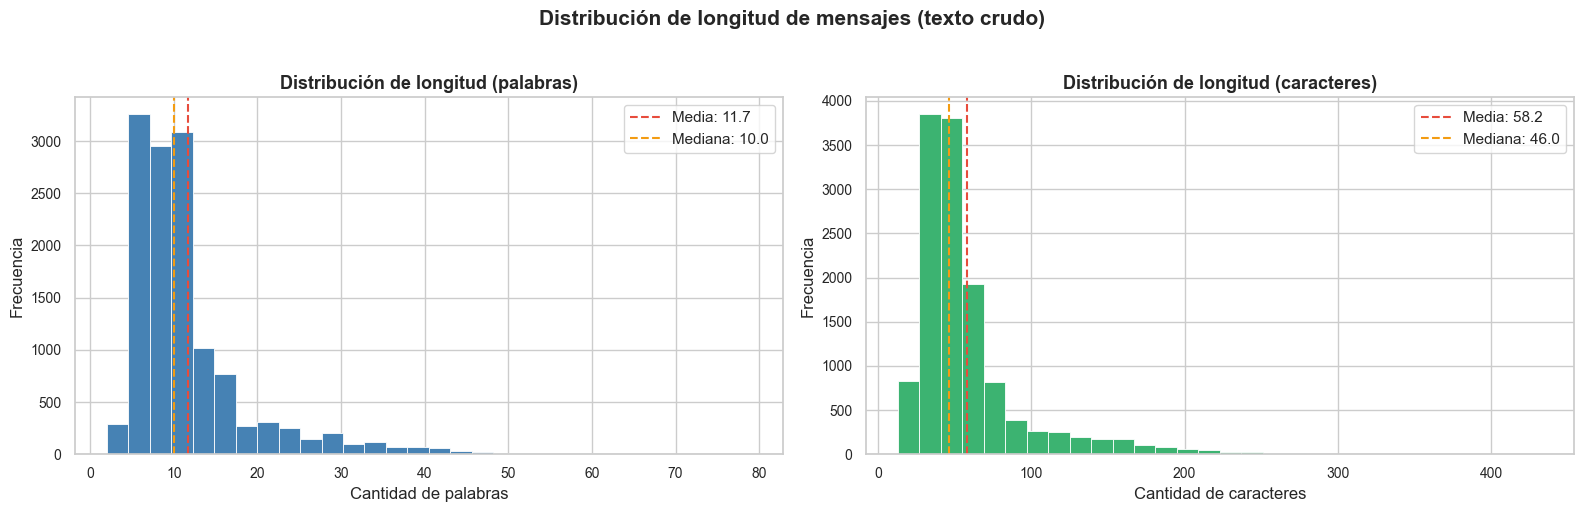

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Distribución en palabras ---
axes[0].hist(df["word_count"], bins=30, color="steelblue", edgecolor="white", linewidth=0.6)
axes[0].axvline(df["word_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['word_count'].mean():.1f}")
axes[0].axvline(df["word_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['word_count'].median():.1f}")
axes[0].set_title("Distribución de longitud (palabras)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Distribución en caracteres ---
axes[1].hist(df["char_count"], bins=30, color="mediumseagreen", edgecolor="white", linewidth=0.6)
axes[1].axvline(df["char_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['char_count'].mean():.1f}")
axes[1].axvline(df["char_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['char_count'].median():.1f}")
axes[1].set_title("Distribución de longitud (caracteres)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cantidad de caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.suptitle("Distribución de longitud de mensajes (texto crudo)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


C:\Users\Gonza Gaitan\AppData\Local\Temp\ipykernel_5036\1844427921.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


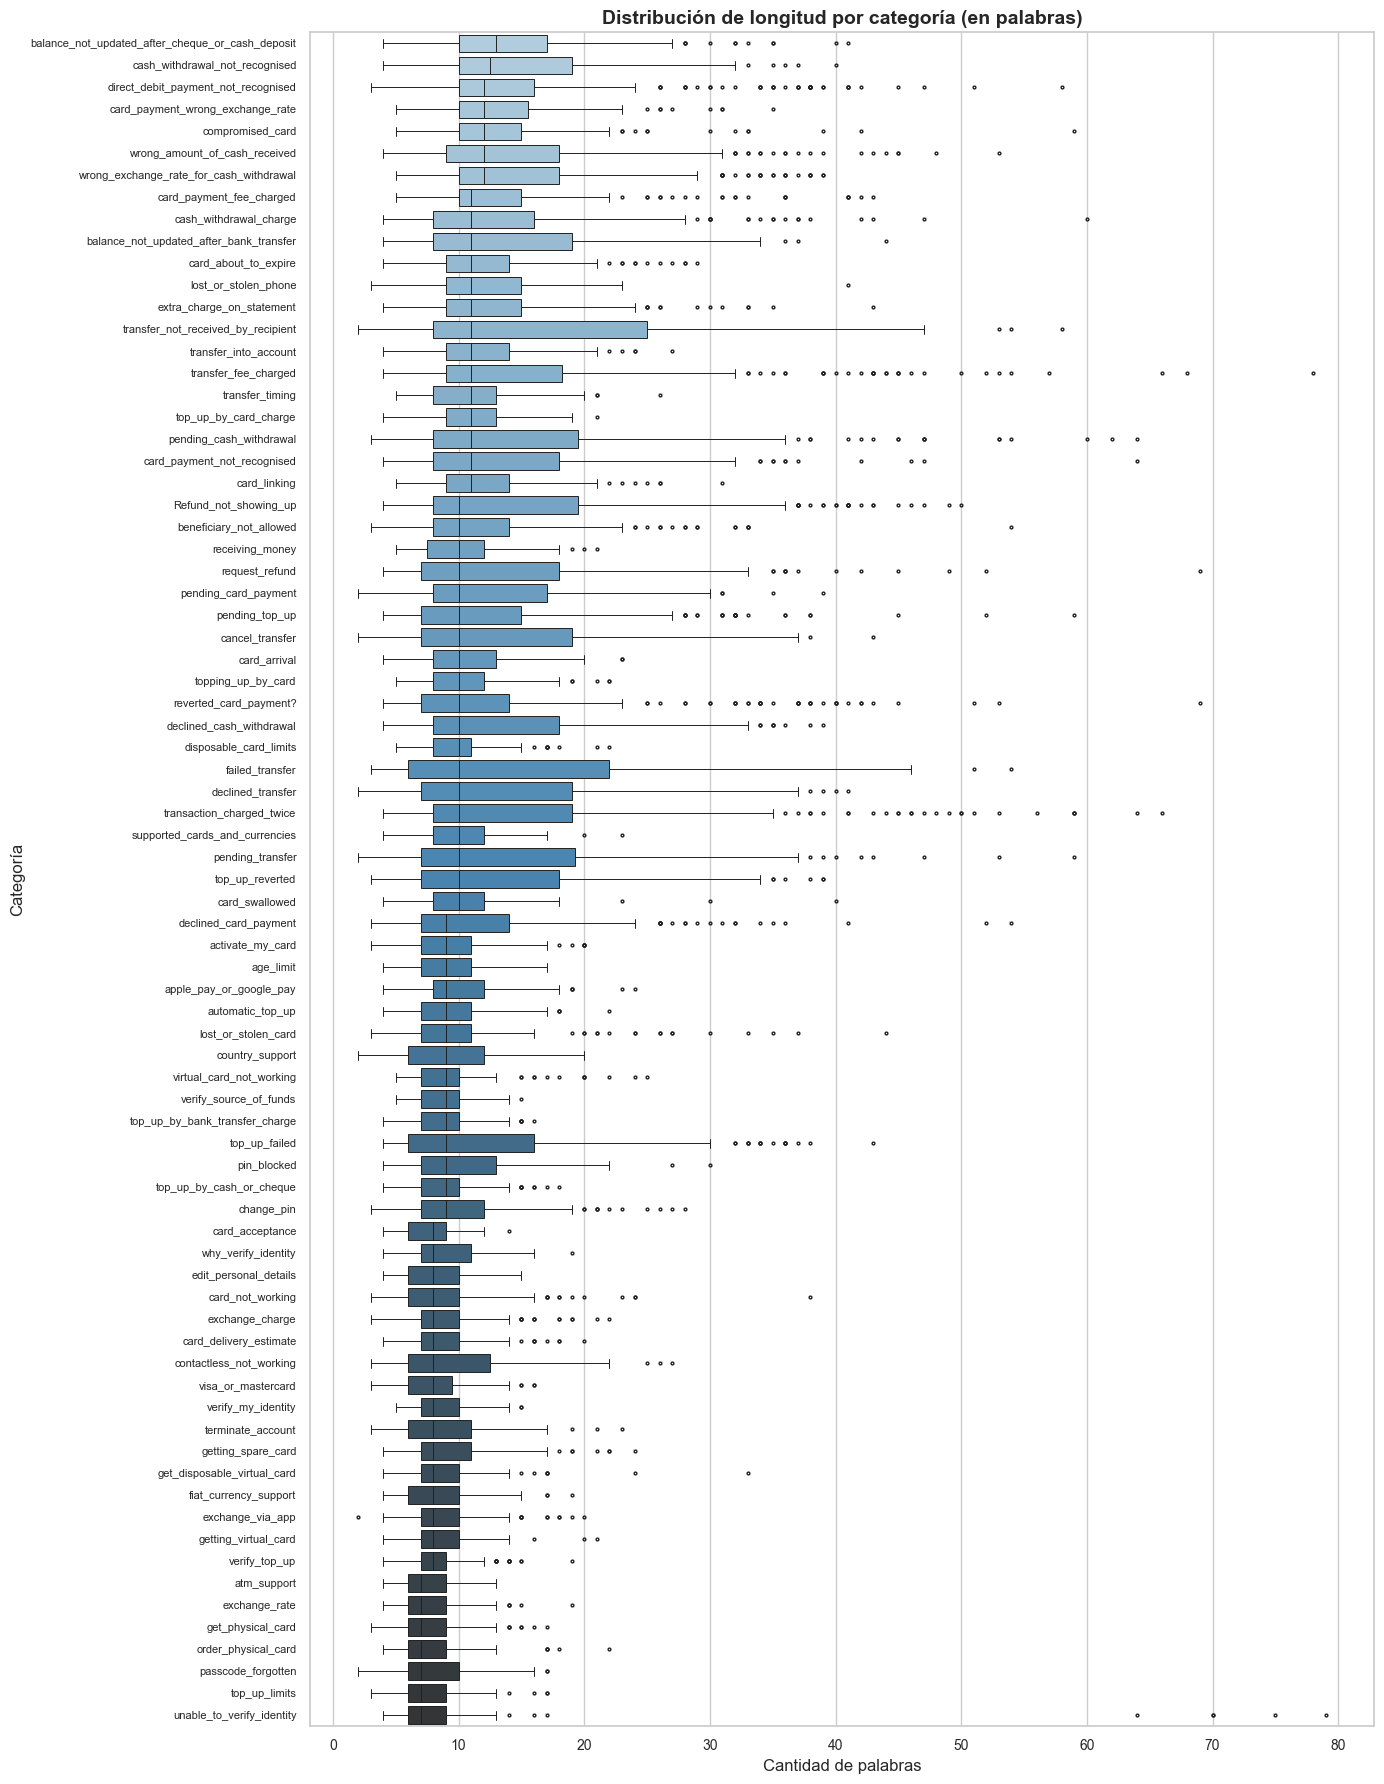

In [33]:
# Ordenamos por mediana de word_count para que sea legible
order = (df.groupby("category")["word_count"]
           .median()
           .sort_values(ascending=False)
           .index)

fig, ax = plt.subplots(figsize=(14, 18))
sns.boxplot(
    data=df,
    x="word_count",
    y="category",
    order=order,
    palette="Blues_d",
    linewidth=0.7,
    fliersize=2,
    ax=ax
)
ax.set_title("Distribución de longitud por categoría (en palabras)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de palabras")
ax.set_ylabel("Categoría")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


In [34]:
# Definimos outliers como mensajes fuera de 1.5 * IQR
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

muy_cortos = df[df["word_count"] <= 3]
muy_largos = df[df["word_count"] > Q3 + 1.5 * IQR]

print(f"Mensajes muy cortos (≤ 3 palabras): {len(muy_cortos)} ({100*len(muy_cortos)/len(df):.2f}%)")
print(f"Mensajes muy largos (> Q3 + 1.5·IQR = {Q3 + 1.5*IQR:.0f} palabras): {len(muy_largos)} ({100*len(muy_largos)/len(df):.2f}%)")

print("\n--- Ejemplos de mensajes muy cortos ---")
print(muy_cortos[["text", "category", "word_count"]].head(10).to_string(index=False))

print("\n--- Ejemplos de mensajes muy largos ---")
print(muy_largos[["text", "category", "word_count"]].sort_values("word_count", ascending=False).head(5).to_string(index=False))


Mensajes muy cortos (≤ 3 palabras): 49 (0.37%)
Mensajes muy largos (> Q3 + 1.5·IQR = 22 palabras): 1118 (8.55%)

--- Ejemplos de mensajes muy cortos ---
                         text                category  word_count
  withdrawal pending meaning? pending_cash_withdrawal           3
Explain pending transactions. pending_cash_withdrawal           3
           Report stolen card     lost_or_stolen_card           3
         Cancel a transaction         cancel_transfer           3
         stop the transaction         cancel_transfer           3
           Cancel Transaction         cancel_transfer           2
     Cancelling a transaction         cancel_transfer           3
       Are top-ups unlimited?           top_up_limits           3
          top up cancellation         top_up_reverted           3
  Explain top-up cancellation         top_up_reverted           3

--- Ejemplos de mensajes muy largos ---
                                                                                